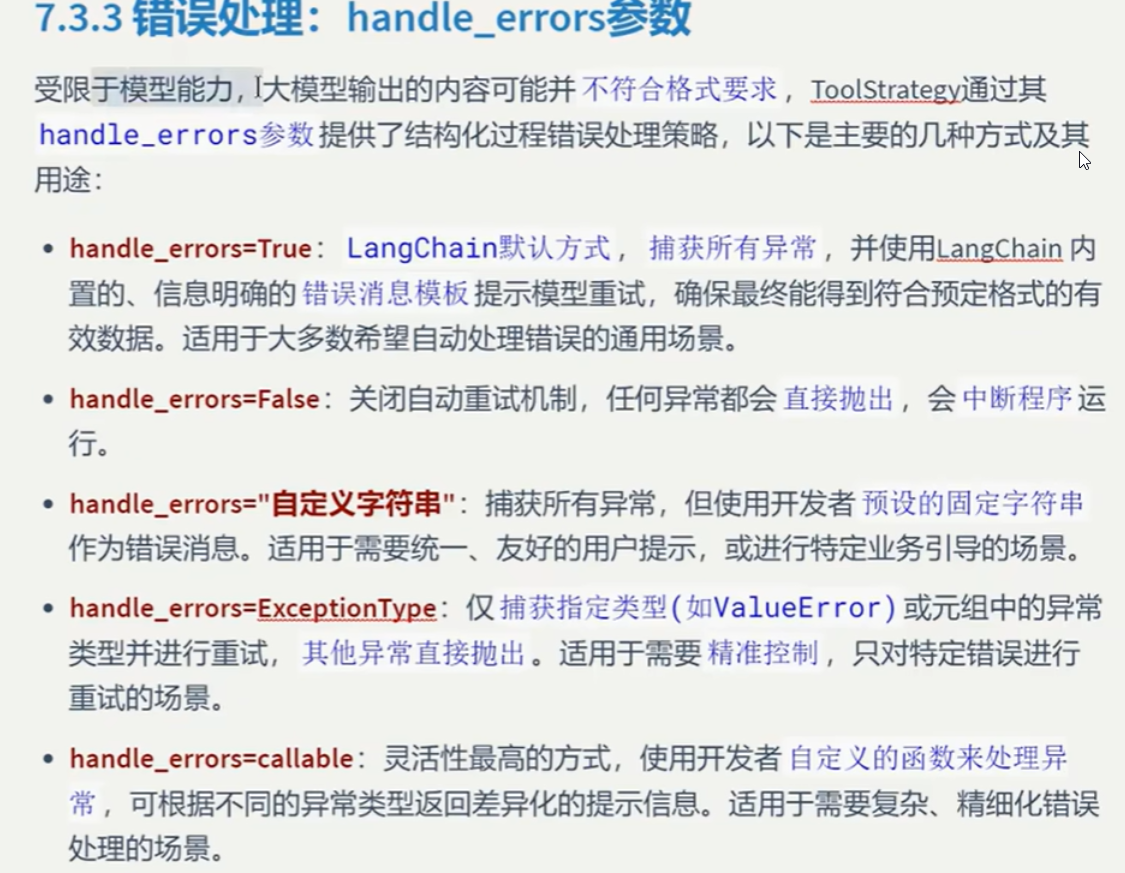

## 情况1：设置为True/False/固定字符串
举例1 handle_errors= True

In [1]:
from typing import Union

from langchain.agents.structured_output import ToolStrategy
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")

class EnventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")

agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EnventDetails,], ## 注意Union里面的东西只能取一个
        tool_message_content="提取完成！",
        handle_errors=True
    )
)


result = agent.invoke({
    "messages":[{
        "role":"user",
        "content":"请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-7-15"
    }]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-
7-15',
            additional_kwargs={},
            response_metadata={},
            id='b4ef1841-a215-494c-a7c8-8c4b3a210d33'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 227,
                    'prompt_tokens': 280,
                    'total_tokens': 507,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-985',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11927-32ab-72e0-b174-1b5696196f5a-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_zrnbujbr',
                    'type': 'tool_call'
                },
                {
                    'name': 'EnventDetails',
                    'args': {'event_name': '公司年会', 'date': '2026-7-15'},
                    'id': 'call_k28e1umq',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 280,
                'output_tokens': 227,
                'total_tokens': 507,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='ContactInfo',
            id='43c355bc-04fe-492c-9d59-8d092b503a29',
            tool_call_id='call_zrnbujbr'
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='EnventDetails',
            id='26eca0c3-61ba-43fb-b92a-6fcbde32acbb',
            tool_call_id='call_k28e1umq'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 240,
                    'prompt_tokens': 424,
                    'total_tokens': 664,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 276}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-637',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11928-7788-7400-8752-499b700da8c5-0',
            tool_calls=[
                {
                    'name': 'EnventDetails',
                    'args': {'date': '2026-7-15', 'event_name': '公司年会'},
                    'id': 'call_fy5tle55',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 424,
                'output_tokens': 240,
                'total_tokens': 664,
                'input_token_details': {'cache_read': 276},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='提取完成！',
       

### 举例2 hanlde_errors=False，没有捕获异常，程序会崩溃

In [2]:
from typing import Union

from langchain.agents.structured_output import ToolStrategy
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")

class EnventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")

agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EnventDetails,], ## 注意Union里面的东西只能取一个
        tool_message_content="提取完成！",
        handle_errors=False #不捕获异常，程序就会崩溃
    )
)


result = agent.invoke({
    "messages":[{
        "role":"user",
        "content":"请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-7-15"
    }]
})

rprint(result)

MultipleStructuredOutputsError: Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) when only one is expected.

### 举例3.handle_error=一个字符串

In [3]:
from typing import Union

from langchain.agents.structured_output import ToolStrategy
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")

class EnventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")

agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EnventDetails,], ## 注意Union里面的东西只能取一个
        tool_message_content="提取完成！",
        handle_errors="请检查输入数据"
    )
)


result = agent.invoke({
    "messages":[{
        "role":"user",
        "content":"请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-7-15"
    }]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-
7-15',
            additional_kwargs={},
            response_metadata={},
            id='c4e3fcf7-e946-4c23-81bb-5909d59894c2'
        ),
        AIMessage(
            content='我将为您编写一个解析函数，从文本中提取联系人信息和活动详情：\n\n',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 230,
                    'prompt_tokens': 280,
                    'total_tokens': 510,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 276}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-983',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1192c-4b6c-77c2-bd1d-0843441069fc-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_35akn9uy',
                    'type': 'tool_call'
                },
                {
                    'name': 'EnventDetails',
                    'args': {'event_name': '公司年会', 'date': '2026-7-15'},
                    'id': 'call_bvs4ydje',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 280,
                'output_tokens': 230,
                'total_tokens': 510,
                'input_token_details': {'cache_read': 276},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='请检查输入数据',
            name='ContactInfo',
            id='a3d16720-8bf8-4342-81ab-0d246aa3fac0',
            tool_call_id='call_35akn9uy'
        ),
        ToolMessage(
            content='请检查输入数据',
            name='EnventDetails',
            id='7a8e9683-b749-4a4d-afe5-981f820f0249',
            tool_call_id='call_bvs4ydje'
        ),
        AIMessage(
            content='根据您提供的文本内容，我已提取出以下结构化信息：\n\n| 字段 | 内容 |\n|------|------|\n| 
**姓名** | 张三 |\n| **电子邮箱** | zhang3@atguigu.com |\n| **活动名称** | 公司年会 |\n| **活动日期** | 2026-7-15 
|\n\n---\n\n### 结构化数据表示：\n\n```json\n{\n  "contact": {\n    "name": "张三",\n    "email": 
"zhang3@atguigu.com"\n  },\n  "event": {\n    "name": "公司年会",\n    "date": "2026-7-15"\n  
}\n}\n```\n\n需要我帮您将这些信息存入数据库、发送邮件通知，还是生成其他格式的文件吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 288,
                    'prompt_tokens': 392,
                    'total_tokens': 680,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 276}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-72',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1192d-05a0-7760-8f1e-ec0aed1bce3b-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 392,
                'output_tokens': 288,
                'total_tokens': 680,
                'input_token_details': {'cache_read': 276},
                'output_token_details': {}
            }
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                

## 情况2：设置为指定异常类型
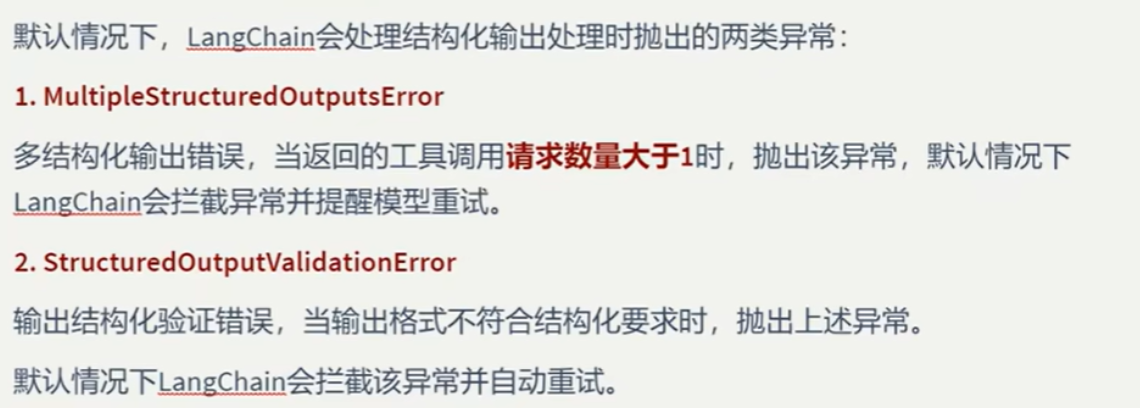

In [4]:
from typing import Union

from langchain.agents.structured_output import ToolStrategy,MultipleStructuredOutputsError,StructuredOutputValidationError
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="qwen3-vl:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")

class EnventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")

agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EnventDetails,], ## 注意Union里面的东西只能取一个
        tool_message_content="提取完成！",
        handle_errors=(MultipleStructuredOutputsError,StructuredOutputValidationError)
    )
)


result = agent.invoke({
    "messages":[{
        "role":"user",
        "content":"请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-7-15"
    }]
})

rprint(result)

{
    'messages': [
        HumanMessage(
            content='请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-
7-15',
            additional_kwargs={},
            response_metadata={},
            id='2589ab68-463a-4005-8b9d-34913a453baf'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 204,
                    'prompt_tokens': 280,
                    'total_tokens': 484,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 276}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-337',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11930-a4fc-7721-a642-318db97fec38-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_xioa5pks',
                    'type': 'tool_call'
                },
                {
                    'name': 'EnventDetails',
                    'args': {'event_name': '公司年会', 'date': '2026-7-15'},
                    'id': 'call_jrmfa5gf',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 280,
                'output_tokens': 204,
                'total_tokens': 484,
                'input_token_details': {'cache_read': 276},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='ContactInfo',
            id='14e9ab38-f0a9-4581-ab7d-56a6e5e530b1',
            tool_call_id='call_xioa5pks'
        ),
        ToolMessage(
            content='Error: Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) 
when only one is expected.\n Please fix your mistakes.',
            name='EnventDetails',
            id='d9ddd046-1561-4fed-b1e7-345646d8e4f7',
            tool_call_id='call_jrmfa5gf'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 314,
                    'prompt_tokens': 424,
                    'total_tokens': 738,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 276}
                },
                'model_provider': 'openai',
                'model_name': 'carstenuhlig/omnicoder-9b:latest',
                'system_fingerprint': 'fp_ollama',
                'id': 'chatcmpl-57',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a11931-692e-7521-99cb-98084beff4cc-0',
            tool_calls=[
                {
                    'name': 'ContactInfo',
                    'args': {'name': '张三', 'email': 'zhang3@atguigu.com'},
                    'id': 'call_9for3yqw',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 424,
                'output_tokens': 314,
                'total_tokens': 738,
                'input_token_details': {'cache_read': 276},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='提取完成！',
    

## 情况3：设置为自定义错误处理函数
### 举例


In [ ]:
from typing import Union

from langchain.agents.structured_output import ToolStrategy,MultipleStructuredOutputsError,StructuredOutputValidationError
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from rich import print as rprint
# 1.初始化模型
model = ChatOpenAI(
    model="carstenuhlig/omnicoder-9b:latest",
    # model="mistral-nemo:latest",
    api_key="sk12345",
    base_url="http://localhost:11434/v1",
)

class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")

class EnventDetails(BaseModel):
    """活动详情"""
    event_name: str = Field(description="活动名称")
    date: str = Field(description="活动日期")

## 定义错误处理函数
def my_error_handler(error: Exception):
    """自定义错误处理函数"""
    err_str = str(error)
    print(f"捕获到错误类型{type(error).__name__}")
    print(f"错误详情{err_str}")
    if isinstance(error, StructuredOutputValidationError):
        return "评价数据格式有误，请检查字段是否符合要求。请重新分析评价内容"
    elif isinstance(error, MultipleStructuredOutputsError):
        return "检测到多个响应，请选择最相关的一个进行返回"
    else:
        return f"Error: {err_str}"

agent = create_agent(
    model=model,
    response_format=ToolStrategy(
        Union[ContactInfo, EnventDetails,], ## 注意Union里面的东西只能取一个
        tool_message_content="提取完成！",
        handle_errors=my_error_handler
    )
)


result = agent.invoke({
    "messages":[{
        "role":"user",
        "content":"请提取以下文本中的内容：张三，电子邮箱：zhang3@atguigu.com,活动名称：公司年会，活动日期：2026-7-15"
    }]
})

rprint(result)

捕获到错误类型MultipleStructuredOutputsError
错误详情Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) when only one is expected.
捕获到错误类型MultipleStructuredOutputsError
错误详情Model incorrectly returned multiple structured responses (ContactInfo, EnventDetails) when only one is expected.
